In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import joblib

In [ ]:
import pandas as pd

# Update the path if needed
df = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\TIM\\Smart_Expense\\backend\\transactions\\scripts\\exported_csvs\\simulated_transactions_realistic.csv")

# Quick view
df.head()


In [33]:
df.tail()


,transaction_id,employee,amount,currency,transaction_type,merchant,description,transaction_date,uploaded_at,risk_score,is_flagged,source
595,TXN-00596,employee_3,1713.42,KES,expense,Client B,Fuel reimbursement,2025-03-02 09:00:00,2026-02-10 16:48:05.680708,0,0,simulated
596,TXN-00597,employee_8,986.95,KES,refund,Client A,Fuel reimbursement,2025-01-15 01:00:00,2026-02-10 16:48:05.680732,20,0,simulated
597,TXN-00598,employee_1,714.63,KES,expense,Fuel Station,Urgent procurement,2025-03-18 16:00:00,2026-02-10 16:48:05.680756,0,0,simulated
598,TXN-00599,employee_5,1290.45,KES,expense,Client A,Refund processed,2025-01-23 17:00:00,2026-02-10 16:48:05.680779,0,0,simulated
599,TXN-00600,employee_7,1432.18,KES,refund,Client B,Ad-hoc expense,2025-03-27 03:00:00,2026-02-10 16:48:05.680818,20,0,simulated


In [ ]:
df["risk_score"].value_counts().sort_index()


In [21]:
df["risk_score"].value_counts().sort_index()

risk_score
0      362
20     180
30      14
40      13
50      15
60      11
70       1
80       3
110      1
Name: count, dtype: int64

In [3]:
df["amount"].value_counts().sort_index()


amount
21.14       1
23.82       1
27.03       1
27.62       1
37.25       1
           ..
12399.84    1
12472.85    1
13731.49    1
13837.69    1
17251.78    1
Name: count, Length: 598, dtype: int64

In [24]:
df["employee"].value_counts().sort_index()

employee
employee_1    75
employee_2    78
employee_3    84
employee_4    56
employee_5    78
employee_6    70
employee_7    77
employee_8    82
Name: count, dtype: int64

In [48]:
df["transaction_type"].value_counts().sort_index()

transaction_type
expense    175
refund     228
sale       197
Name: count, dtype: int64

In [31]:
df.head()

,transaction_id,employee,amount,currency,merchant,description,transaction_date,uploaded_at,risk_score,is_flagged,source,employee_enc,merchant_enc,currency_enc,source_enc,type_expense,type_refund,type_sale
0,TXN-00001,employee_5,1351.24,KES,Tech World,Refund processed,2025-02-09 08:00:00,2026-02-10 16:48:05.663942,30,0,simulated,4,7,0,0,False,True,False
1,TXN-00002,employee_5,1739.40,KES,Client A,Office supplies purchase,2025-03-20 01:00:00,2026-02-10 16:48:05.664030,20,0,simulated,4,1,0,0,False,False,True
2,TXN-00003,employee_3,1676.89,KES,Client A,Office supplies purchase,2025-02-11 11:00:00,2026-02-10 16:48:05.664073,0,0,simulated,2,1,0,0,True,False,False
3,TXN-00004,employee_8,772.29,KES,Cafe Express,Office supplies purchase,2025-03-23 03:00:00,2026-02-10 16:48:05.664107,20,0,simulated,7,0,0,0,True,False,False
4,TXN-00005,employee_6,550.30,KES,Online Store,Client payment,2025-03-22 08:00:00,2026-02-10 16:48:05.664148,0,0,simulated,5,6,0,0,True,False,False


In [4]:
df = df.drop(columns=[
    'transaction_id',
    'description',
    'uploaded_at',
])

In [5]:
df.head()


,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source
0,employee_5,1351.24,KES,refund,Tech World,2025-02-09 08:00:00,30,0,simulated
1,employee_5,1739.40,KES,sale,Client A,2025-03-20 01:00:00,20,0,simulated
2,employee_3,1676.89,KES,expense,Client A,2025-02-11 11:00:00,0,0,simulated
3,employee_8,772.29,KES,expense,Cafe Express,2025-03-23 03:00:00,20,0,simulated
4,employee_6,550.30,KES,expense,Online Store,2025-03-22 08:00:00,0,0,simulated


In [6]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df = df.sort_values('transaction_date')

In [56]:
df.head()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn,hour,day_of_week
368,employee_4,397.19,KES,refund,Online Store,2025-01-01 02:00:00,50,1,simulated,999.000,2,2
174,employee_2,1739.53,KES,refund,Local Supplier,2025-01-01 02:00:00,20,0,simulated,999.000,2,2
122,employee_1,275.00,KES,expense,Online Store,2025-01-01 04:00:00,20,0,simulated,999.000,4,2
185,employee_2,1421.72,KES,expense,Fuel Station,2025-01-01 05:00:00,20,0,simulated,0.125,5,2
530,employee_2,1154.80,KES,refund,Client B,2025-01-01 05:00:00,20,0,simulated,0.000,5,2


In [7]:
df['days_since_last_txn'] = (
    df.groupby('employee')['transaction_date']
    .diff()
    .dt.total_seconds() / (60 * 60 *24)
)

In [8]:
df['days_since_last_txn'] = df['days_since_last_txn'].fillna(999)

In [9]:
df.head()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn
368,employee_4,397.19,KES,refund,Online Store,2025-01-01 02:00:00,50,1,simulated,999.000
174,employee_2,1739.53,KES,refund,Local Supplier,2025-01-01 02:00:00,20,0,simulated,999.000
122,employee_1,275.00,KES,expense,Online Store,2025-01-01 04:00:00,20,0,simulated,999.000
185,employee_2,1421.72,KES,expense,Fuel Station,2025-01-01 05:00:00,20,0,simulated,0.125
530,employee_2,1154.80,KES,refund,Client B,2025-01-01 05:00:00,20,0,simulated,0.000


In [10]:
df['hour'] = df['transaction_date'].dt.hour

In [11]:
df['day_of_week'] = df['transaction_date'].dt.dayofweek

In [12]:
df.head()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn,hour,day_of_week
368,employee_4,397.19,KES,refund,Online Store,2025-01-01 02:00:00,50,1,simulated,999.000,2,2
174,employee_2,1739.53,KES,refund,Local Supplier,2025-01-01 02:00:00,20,0,simulated,999.000,2,2
122,employee_1,275.00,KES,expense,Online Store,2025-01-01 04:00:00,20,0,simulated,999.000,4,2
185,employee_2,1421.72,KES,expense,Fuel Station,2025-01-01 05:00:00,20,0,simulated,0.125,5,2
530,employee_2,1154.80,KES,refund,Client B,2025-01-01 05:00:00,20,0,simulated,0.000,5,2


### splitting chronologically


In [46]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

In [16]:
categorical_cols = ["employee", "transaction_type"]

### One hot encoding

In [17]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(train_df[categorical_cols])


OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [18]:
X_train_encoded = encoder.transform(train_df[categorical_cols])
X_test_encoded = encoder.transform(test_df[categorical_cols])

### Combining numeric features

In [19]:
numeric_cols = ["amount", "days_since_last_txn", "hour", "day_of_week"]

X_train = np.hstack([
    train_df[numeric_cols].values,
    X_train_encoded
])

X_test = np.hstack([
    test_df[numeric_cols].values,
    X_test_encoded
])


In [20]:
y_train = train_df["risk_score"]
y_test  = test_df["risk_score"]


In [59]:
df.head()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn,hour,day_of_week
368,employee_4,397.19,KES,refund,Online Store,2025-01-01 02:00:00,50,1,simulated,999.000,2,2
174,employee_2,1739.53,KES,refund,Local Supplier,2025-01-01 02:00:00,20,0,simulated,999.000,2,2
122,employee_1,275.00,KES,expense,Online Store,2025-01-01 04:00:00,20,0,simulated,999.000,4,2
185,employee_2,1421.72,KES,expense,Fuel Station,2025-01-01 05:00:00,20,0,simulated,0.125,5,2
530,employee_2,1154.80,KES,refund,Client B,2025-01-01 05:00:00,20,0,simulated,0.000,5,2


In [21]:
print(X_train.shape)
print(X_test.shape)


(480, 15)
(120, 15)


In [22]:
print(X_train[:5])


[[3.97190e+02 9.99000e+02 2.00000e+00 2.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00]
 [1.73953e+03 9.99000e+02 2.00000e+00 2.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00]
 [2.75000e+02 9.99000e+02 4.00000e+00 2.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00]
 [1.42172e+03 1.25000e-01 5.00000e+00 2.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00]
 [1.15480e+03 0.00000e+00 5.00000e+00 2.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00]]


In [ ]:
import pandas as pd

# Suppose you have:
numeric_cols = ["amount", "days_since_last_transaction", "day_of_week", "hour"]
# And one-hot encoded column names:
encoded_cols = encoder.get_feature_names_out(categorical_cols)

all_cols = list(numeric_cols) + list(encoded_cols)

X_train_df = pd.DataFrame(X_train, columns=all_cols)
print(X_train_df.head())


plt.hist(df['amount'], bins=50)
plt.show()

In [13]:
df["amount_log"] = np.log1p(df["amount"])

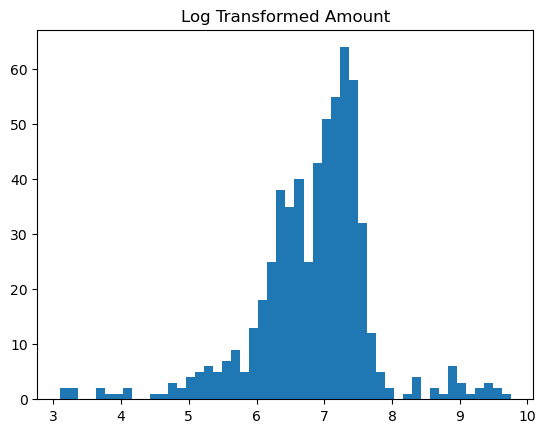

In [14]:
plt.hist(df["amount_log"], bins=50)
plt.title("Log Transformed Amount")
plt.show()

## Train the model

In [28]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [27]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [29]:
y_pred = rf.predict(X_test)

In [31]:
mse = mean_squared_error(y_test, y_pred)
print(mse)

45.59891666666667


In [32]:
df["risk_score"].value_counts()

risk_score
0      362
20     180
50      15
30      14
40      13
60      11
80       3
70       1
110      1
Name: count, dtype: int64

In [33]:
rmse = np.sqrt(45.5989)
print(rmse)

6.752695757991766


In [35]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.8525764705882353


In [36]:
feature_importance = pd.Series(rf.feature_importances_, index=all_cols)
print(feature_importance.sort_values(ascending=False))

day_of_week                    0.507297
amount                         0.361663
days_since_last_transaction    0.048198
hour                           0.021909
transaction_type_refund        0.017385
employee_employee_5            0.008008
employee_employee_6            0.007537
transaction_type_expense       0.005345
employee_employee_2            0.004215
transaction_type_sale          0.003811
employee_employee_1            0.003573
employee_employee_8            0.003562
employee_employee_4            0.003352
employee_employee_3            0.002792
employee_employee_7            0.001353
dtype: float64


In [39]:
joblib.dump(rf, "rf_version1.pkl")

['rf_version1.pkl']

### VERSION 2

In [60]:
employee_avg = train_df.groupby("employee")["amount"].mean()
employee_count = train_df.groupby("employee")["amount"].count()

In [61]:
df.head()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn,hour,day_of_week,amount_log
368,employee_4,397.19,KES,refund,Online Store,2025-01-01 02:00:00,50,1,simulated,999.000,2,2,5.986929
174,employee_2,1739.53,KES,refund,Local Supplier,2025-01-01 02:00:00,20,0,simulated,999.000,2,2,7.461945
122,employee_1,275.00,KES,expense,Online Store,2025-01-01 04:00:00,20,0,simulated,999.000,4,2,5.620401
185,employee_2,1421.72,KES,expense,Fuel Station,2025-01-01 05:00:00,20,0,simulated,0.125,5,2,7.260326
530,employee_2,1154.80,KES,refund,Client B,2025-01-01 05:00:00,20,0,simulated,0.000,5,2,7.052548


In [62]:
train_df["employee_avg_amount"] = train_df["employee"].map(employee_avg)
train_df["employee_txn_count"] = train_df["employee"].map(employee_count)
train_df["amount_deviation"] = (
    train_df["amount"] - train_df["employee_avg_amount"]
)

In [63]:
train_df.head()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn,hour,day_of_week,amount_log,employee_avg_amount,employee_txn_count,amount_deviation
368,employee_4,397.19,KES,refund,Online Store,2025-01-01 02:00:00,50,1,simulated,999.000,2,2,5.986929,1648.033571,42,-1250.843571
174,employee_2,1739.53,KES,refund,Local Supplier,2025-01-01 02:00:00,20,0,simulated,999.000,2,2,7.461945,1893.596250,64,-154.066250
122,employee_1,275.00,KES,expense,Online Store,2025-01-01 04:00:00,20,0,simulated,999.000,4,2,5.620401,466.896406,64,-191.896406
185,employee_2,1421.72,KES,expense,Fuel Station,2025-01-01 05:00:00,20,0,simulated,0.125,5,2,7.260326,1893.596250,64,-471.876250
530,employee_2,1154.80,KES,refund,Client B,2025-01-01 05:00:00,20,0,simulated,0.000,5,2,7.052548,1893.596250,64,-738.796250


In [53]:
train_df.tail()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn,hour,day_of_week,amount_log,employee_avg_amount,employee_txn_count,amount_deviation
343,employee_5,976.18,KES,refund,Client A,2025-03-13 13:00:00,0,0,simulated,1.958333,13,3,6.884671,1402.974921,63,-426.794921
453,employee_5,763.44,KES,sale,Local Supplier,2025-03-13 15:00:00,0,0,simulated,0.083333,15,3,6.639144,1402.974921,63,-639.534921
412,employee_2,1275.96,KES,expense,Client A,2025-03-14 00:00:00,20,0,simulated,0.500000,0,4,7.152238,1893.596250,64,-617.636250
173,employee_3,1251.59,KES,expense,Online Store,2025-03-14 04:00:00,20,0,simulated,0.791667,4,4,7.132969,1946.304928,69,-694.714928
212,employee_6,378.90,KES,refund,Local Supplier,2025-03-14 08:00:00,0,0,simulated,1.875000,8,4,5.939908,589.738000,50,-210.838000


In [54]:
train_df["amount"].describe()

count      480.000000
mean      1326.686021
std       1614.374131
min         21.140000
25%        595.210000
50%       1065.590000
75%       1518.945000
max      13837.690000
Name: amount, dtype: float64

In [64]:
test_df["employee_avg_amount"] = test_df["employee"].map(employee_avg)
test_df["employee_txn_count"] = test_df["employee"].map(employee_count)

test_df["amount_deviation"] = (
    test_df["amount"] - test_df["employee_avg_amount"]
)

test_df.fillna(0, inplace=True)


In [65]:
train_df.head()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn,hour,day_of_week,amount_log,employee_avg_amount,employee_txn_count,amount_deviation
368,employee_4,397.19,KES,refund,Online Store,2025-01-01 02:00:00,50,1,simulated,999.000,2,2,5.986929,1648.033571,42,-1250.843571
174,employee_2,1739.53,KES,refund,Local Supplier,2025-01-01 02:00:00,20,0,simulated,999.000,2,2,7.461945,1893.596250,64,-154.066250
122,employee_1,275.00,KES,expense,Online Store,2025-01-01 04:00:00,20,0,simulated,999.000,4,2,5.620401,466.896406,64,-191.896406
185,employee_2,1421.72,KES,expense,Fuel Station,2025-01-01 05:00:00,20,0,simulated,0.125,5,2,7.260326,1893.596250,64,-471.876250
530,employee_2,1154.80,KES,refund,Client B,2025-01-01 05:00:00,20,0,simulated,0.000,5,2,7.052548,1893.596250,64,-738.796250


In [72]:
numeric_cols = [
    "amount",
    "days_since_last_txn",
    "day_of_week",
    "hour",
    "employee_avg_amount",
    "employee_txn_count",
    "amount_deviation"
]


In [67]:
categorical_cols = ["employee", "transaction_type"]

In [69]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(train_df[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [70]:
X_train_encoded = pd.DataFrame(
    encoder.transform(train_df[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=train_df.index
)

X_test_encoded = pd.DataFrame(
    encoder.transform(test_df[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=test_df.index
)

In [73]:
X_train = pd.concat([train_df[numeric_cols], X_train_encoded], axis=1)
X_test  = pd.concat([test_df[numeric_cols], X_test_encoded], axis=1)

print(X_train.head())
print(X_test.head())

      amount  days_since_last_txn  day_of_week  hour  employee_avg_amount  \
368   397.19              999.000            2     2          1648.033571   
174  1739.53              999.000            2     2          1893.596250   
122   275.00              999.000            2     4           466.896406   
185  1421.72                0.125            2     5          1893.596250   
530  1154.80                0.000            2     5          1893.596250   

     employee_txn_count  amount_deviation  employee_employee_1  \
368                  42      -1250.843571                  0.0   
174                  64       -154.066250                  0.0   
122                  64       -191.896406                  1.0   
185                  64       -471.876250                  0.0   
530                  64       -738.796250                  0.0   

     employee_employee_2  employee_employee_3  employee_employee_4  \
368                  0.0                  0.0                  1.0   


In [74]:
y_train = train_df["risk_score"]
y_test = test_df["risk_score"]

In [75]:
rf_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [76]:
rf_v2.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [77]:
y_pred = rf_v2.predict(X_test)

In [78]:
mse_v2 = mean_squared_error(y_test, y_pred)
r2_v2 = r2_score(y_test, y_pred)

In [79]:
print(mse_v2)
print(r2_v2)

51.19883333333334
0.8344716659182757


In [80]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
print(comparison.head(10))


     Actual  Predicted
273       0        0.3
450      20       22.1
162      20       29.9
166      50       22.4
127      40       34.2
585       0        1.5
211      20       22.1
262       0        3.9
156      20       17.2
548       0        0.6


In [86]:
all_cols = X_train.columns  # this automatically matches rf_v2.feature_importances_
feature_importance_v2 = pd.Series(rf_v2.feature_importances_, index=all_cols)
print(feature_importance.sort_values(ascending=False))



hour                        0.504665
amount                      0.199806
amount_deviation            0.177859
days_since_last_txn         0.041116
transaction_type_refund     0.018184
day_of_week                 0.017422
employee_txn_count          0.008080
employee_avg_amount         0.006350
employee_employee_6         0.004839
employee_employee_5         0.004773
transaction_type_expense    0.003719
transaction_type_sale       0.003401
employee_employee_8         0.002706
employee_employee_2         0.002551
employee_employee_1         0.001690
employee_employee_4         0.001240
employee_employee_7         0.000846
employee_employee_3         0.000754
dtype: float64


In [85]:
joblib.dump(rf_v2, "rf_version2.pkl")

['rf_version2.pkl']

In [87]:
top_features = feature_importance_v2.sort_values(ascending=False).head(10)

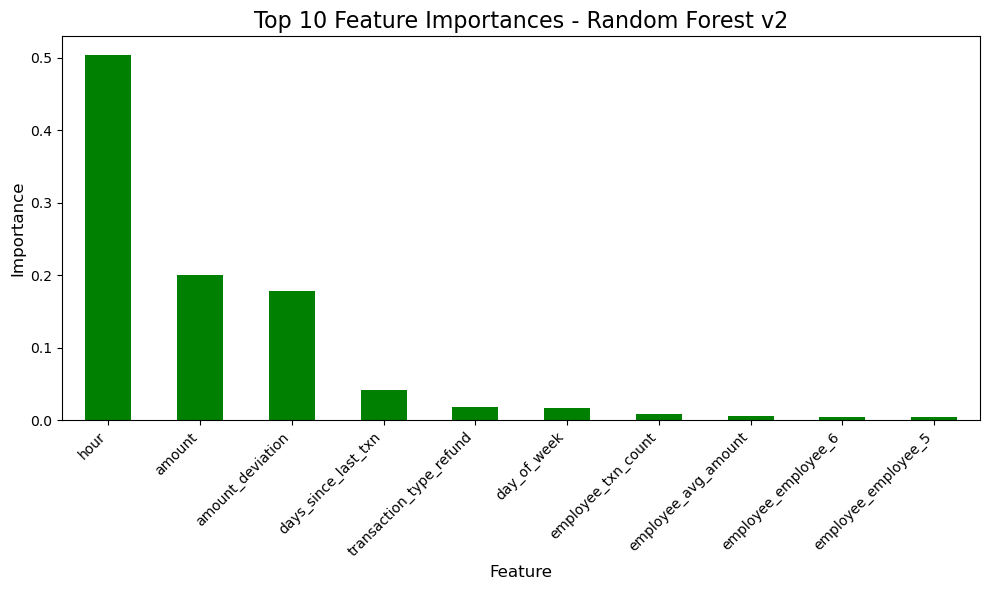

In [88]:
plt.figure(figsize=(10,6))
top_features.plot(kind='bar', color='green')
plt.title("Top 10 Feature Importances - Random Forest v2", fontsize=16)
plt.ylabel("Importance", fontsize=12)
plt.xlabel("Feature", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## EVALUATION

In [94]:
high_risk_threshold = 0.9
test_df["is_flagged"] = (y_pred >= high_risk_threshold).astype(int)

In [95]:
flagged_per_employee = test_df.groupby("employee")["is_flagged"].sum()
print(flagged_per_employee)


employee
employee_1     6
employee_2     9
employee_3     7
employee_4     8
employee_5    10
employee_6    14
employee_7     8
employee_8    14
Name: is_flagged, dtype: int64


In [96]:
from sklearn.metrics import confusion_matrix

# Define high-risk label in both actual and predicted
actual_flag = (y_test >= high_risk_threshold).astype(int)
predicted_flag = (y_pred >= high_risk_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(actual_flag, predicted_flag).ravel()

print(f"True Positives (caught fraud): {tp}")
print(f"False Positives (flagged honest employees): {fp}")
print(f"False Negatives (missed fraud): {fn}")
print(f"True Negatives (correctly ignored): {tn}")


True Positives (caught fraud): 45
False Positives (flagged honest employees): 31
False Negatives (missed fraud): 1
True Negatives (correctly ignored): 43


In [99]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])


# Step 2: Sort by transaction_date for temporal split (important to avoid leakage)
df = df.sort_values('transaction_date').reset_index(drop=True)

# Step 3: Feature engineering
df['days_since_last_txn'] = (
    df.groupby('employee')['transaction_date']
    .diff()
    .dt.total_seconds() / (60 * 60 * 24)
)
df['days_since_last_txn'] = df['days_since_last_txn'].fillna(999)
df['hour'] = df['transaction_date'].dt.hour
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Step 4: Train-test split (80-20, temporal)
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

# Step 5: Compute employee-level features on train_df only (to avoid leakage)
employee_avg = train_df.groupby("employee")["amount"].mean()
employee_count = train_df.groupby("employee")["amount"].count()

# Map to train_df
train_df["employee_avg_amount"] = train_df["employee"].map(employee_avg)
train_df["employee_txn_count"] = train_df["employee"].map(employee_count)
train_df["amount_deviation"] = (
    train_df["amount"] - train_df["employee_avg_amount"]
)

# Map to test_df (will have NaNs for unseen employees)
test_df["employee_avg_amount"] = test_df["employee"].map(employee_avg)
test_df["employee_txn_count"] = test_df["employee"].map(employee_count)
test_df["amount_deviation"] = (
    test_df["amount"] - test_df["employee_avg_amount"]
)

# Fill NaNs in test_df with 0 (as per your original code)
test_df.fillna(0, inplace=True)

# Step 6: Define categorical and numeric columns
categorical_cols = ["employee", "transaction_type"]
numeric_cols = [
    "amount",
    "days_since_last_txn",
    "day_of_week",
    "hour",
    "employee_avg_amount",
    "employee_txn_count",
    "amount_deviation"
]

# Step 7: One-hot encoding
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(train_df[categorical_cols])

X_train_encoded = pd.DataFrame(
    encoder.transform(train_df[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=train_df.index
)

X_test_encoded = pd.DataFrame(
    encoder.transform(test_df[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=test_df.index
)

# Step 8: Combine numeric and encoded features
X_train = pd.concat([train_df[numeric_cols], X_train_encoded], axis=1)
X_test = pd.concat([test_df[numeric_cols], X_test_encoded], axis=1)

# Step 9: Define targets
y_train = train_df["risk_score"]
y_test = test_df["risk_score"]

# Step 10: Train the model
rf_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_v2.fit(X_train, y_train)

# Step 11: Predict and evaluate
y_pred = rf_v2.predict(X_test)
mse_v2 = mean_squared_error(y_test, y_pred)
r2_v2 = r2_score(y_test, y_pred)

print(f"MSE: {mse_v2}")
print(f"R²: {r2_v2}")

# Optional: Print feature importances
importances = rf_v2.feature_importances_
feature_names = X_train.columns
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp}")

MSE: 50.58091666666667
R²: 0.8364694207453974
amount: 0.20357281483425868
days_since_last_txn: 0.04110559934347642
day_of_week: 0.016889682851768503
hour: 0.5071390386659101
employee_avg_amount: 0.00532671868503019
employee_txn_count: 0.007011735742174495
amount_deviation: 0.17320040886935664
employee_employee_1: 0.0019070849060544442
employee_employee_2: 0.003101673549134695
employee_employee_3: 0.0009262127269299687
employee_employee_4: 0.0012683872530562961
employee_employee_5: 0.005794019527161822
employee_employee_6: 0.004831159304709847
employee_employee_7: 0.0008982617307305127
employee_employee_8: 0.0026093725837207336
transaction_type_expense: 0.003659302890330626
transaction_type_refund: 0.01768958243199349
transaction_type_sale: 0.0030689441042023526


In [98]:
df.head()

,employee,amount,currency,transaction_type,merchant,transaction_date,risk_score,is_flagged,source,days_since_last_txn,hour,day_of_week,amount_log
368,employee_4,397.19,KES,refund,Online Store,2025-01-01 02:00:00,50,1,simulated,999.000,2,2,5.986929
174,employee_2,1739.53,KES,refund,Local Supplier,2025-01-01 02:00:00,20,0,simulated,999.000,2,2,7.461945
122,employee_1,275.00,KES,expense,Online Store,2025-01-01 04:00:00,20,0,simulated,999.000,4,2,5.620401
185,employee_2,1421.72,KES,expense,Fuel Station,2025-01-01 05:00:00,20,0,simulated,0.125,5,2,7.260326
530,employee_2,1154.80,KES,refund,Client B,2025-01-01 05:00:00,20,0,simulated,0.000,5,2,7.052548


In [100]:
joblib.dump(rf_v2, "rf_version2.pkl")

['rf_version2.pkl']

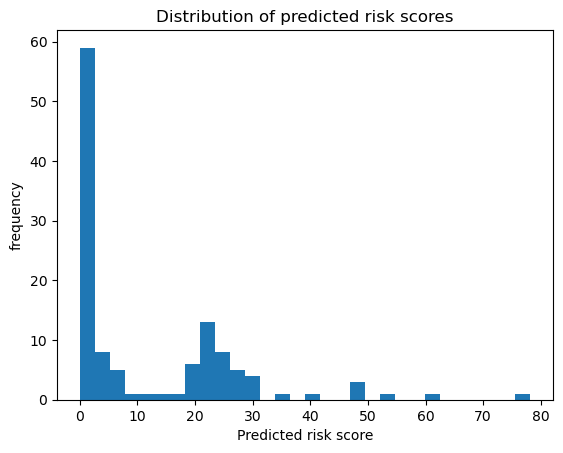

In [101]:
plt.hist(y_pred, bins=30)
plt.title("Distribution of predicted risk scores")
plt.xlabel("Predicted risk score")
plt.ylabel("frequency")
plt.show()

In [102]:
percentiles = [99, 97, 95, 90]

results = []

for p in percentiles:
    threshold = np.percentile(y_pred, p)
    flagged = y_pred >= threshold
    flagged_count = flagged.sum()
    
    results.append((p, threshold, flagged_count))

for r in results:
    print(f"Top {100-r[0]}% | Threshold={r[1]:.2f} | Transactions flagged={r[2]}")


Top 1% | Threshold=59.81 | Transactions flagged=2
Top 3% | Threshold=49.09 | Transactions flagged=4
Top 5% | Threshold=39.63 | Transactions flagged=6
Top 10% | Threshold=28.44 | Transactions flagged=12


In [103]:
for p in percentiles:
    threshold = np.percentile(y_pred, p)
    flagged_df = test_df[y_pred >= threshold]
    
    avg_actual_risk = flagged_df["risk_score"].mean()
    total_amount = flagged_df["amount"].sum()
    
    print(f"\nTop {100-p}%")
    print("Average actual risk:", avg_actual_risk)
    print("Total transaction amount:", total_amount)



Top 1%
Average actual risk: 85.0
Total transaction amount: 22862.510000000002

Top 3%
Average actual risk: 67.5
Total transaction amount: 46887.84

Top 5%
Average actual risk: 61.666666666666664
Total transaction amount: 58161.70999999999

Top 10%
Average actual risk: 45.833333333333336
Total transaction amount: 70894.51000000001


## Computing the threshold for top 10%

In [104]:
threshold_10 = np.percentile(y_pred, 90)
print("Threshold for top 10%;", threshold_10)

Threshold for top 10%; 28.44


In [105]:
test_df["predicted_risk"] = y_pred  # store predictions in your dataframe
test_df["is_flagged"] = (test_df["predicted_risk"] >= threshold_10).astype(int)

# Check how many transactions are flagged
num_flagged = test_df["is_flagged"].sum()
print("Number of transactions flagged (top 10%):", num_flagged)


Number of transactions flagged (top 10%): 12


In [106]:
flagged_transactions = test_df[test_df["is_flagged"] == 1]
print(flagged_transactions[["employee", "amount", "predicted_risk"]])


       employee    amount  predicted_risk
484  employee_7   4142.12            31.1
518  employee_4   9131.02            61.6
537  employee_5   4006.34            39.2
546  employee_1   6773.55            49.2
548  employee_8   5933.16            49.0
549  employee_3  17251.78            52.2
551  employee_8   1482.00            28.8
564  employee_1    156.62            29.9
568  employee_5   5340.71            47.8
585  employee_3   1240.12            30.2
593  employee_5  13731.49            78.2
597  employee_8   1705.60            34.2


In [1]:
joblib.dump(encoder, "encoder_v2.pkl")

NameError: name 'joblib' is not defined